In [1]:
import os
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import MultipleLocator
from PIL import Image
from numpy import concatenate, full
from tqdm import tqdm
from fnn.microns.__init__ import scan
from fnn.microns.build import network
from fnn.microns.load import params, units, unit_ids
from scipy.stats import shapiro, chisquare, poisson, pearsonr
from predict_loop_functions import visual_prediction, generate_noise, ensure_2d_list, get_neuron_units, predict_loop, plot_select30_hist

#### adjusting get_neuron_units() usage

In [10]:
frames = np.full((10,144,256), fill_value = 0)

In [11]:
start = time.time()
x, y, z = predict_loop("constant", 5, frames, 0, [[4,7]], 5)
end = time.time()
print(f"runtime: {end - start:.3f} seconds")

KeyboardInterrupt: 

In [ ]:
print(f"reg. shape: {x.shape}; mean shape: {y.shape}; var shape: {z.shape}")

reg. shape: (10, 5, 7493); mean shape: (10, 7493); var shape: (10, 7493)


#### adjusting inner_predict_loop()

In [ ]:
frames = np.full((10,144,256), fill_value = 0)

In [ ]:
start = time.time()
x, y, z = predict_loop("constant", 5, frames, 0, [[4,7]], 5)
end = time.time()
print(f"runtime: {end - start:.3f} seconds")

runtime: 27.410 seconds


In [ ]:
print(f"reg. shape: {x.shape}; mean shape: {y.shape}; var shape: {z.shape}")

reg. shape: (10, 5, 7493); mean shape: (10, 7493); var shape: (10, 7493)


#### adjusting predict_loop()

In [2]:
frames = np.full((10,144,256), fill_value = 0)

In [19]:
start = time.time()
x, y, z = predict_loop('stochastic binarization', 3, frames, 0, [[4,7]], 5)
end = time.time()
print(f"runtime: {end - start:.3f} seconds")

runtime: 14.305 seconds


In [15]:
start = time.time()
x2, y2, z2 = predict_loop('dynamic', 5, frames, 0, [[4,7]], 5)
end = time.time()
print(f"runtime: {end - start:.3f} seconds")

runtime: 23.696 seconds


In [20]:
print(f"reg. shape: {x.shape}; mean shape: {y.shape}; var shape: {z.shape}")

reg. shape: (10, 3, 7493); mean shape: (10, 7493); var shape: (10, 7493)


In [10]:
type(x)

numpy.ndarray

In [11]:
# for re-run on july 9th
neurons = np.array([1685,368,1571,670,1918,1231,6795,6492,2507,1444,2361,6699,6672,6790,6209,6699,
           1447,5583,2237,2161,7217,5114,4321,4823,6822,5935,823,6501,6819,5782])

C:\Users\joshf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joshf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joshf\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\stats\_axis_nan_policy.py:573: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\joshf\AppData\Local\Packages\PythonSoftwareFoundatio

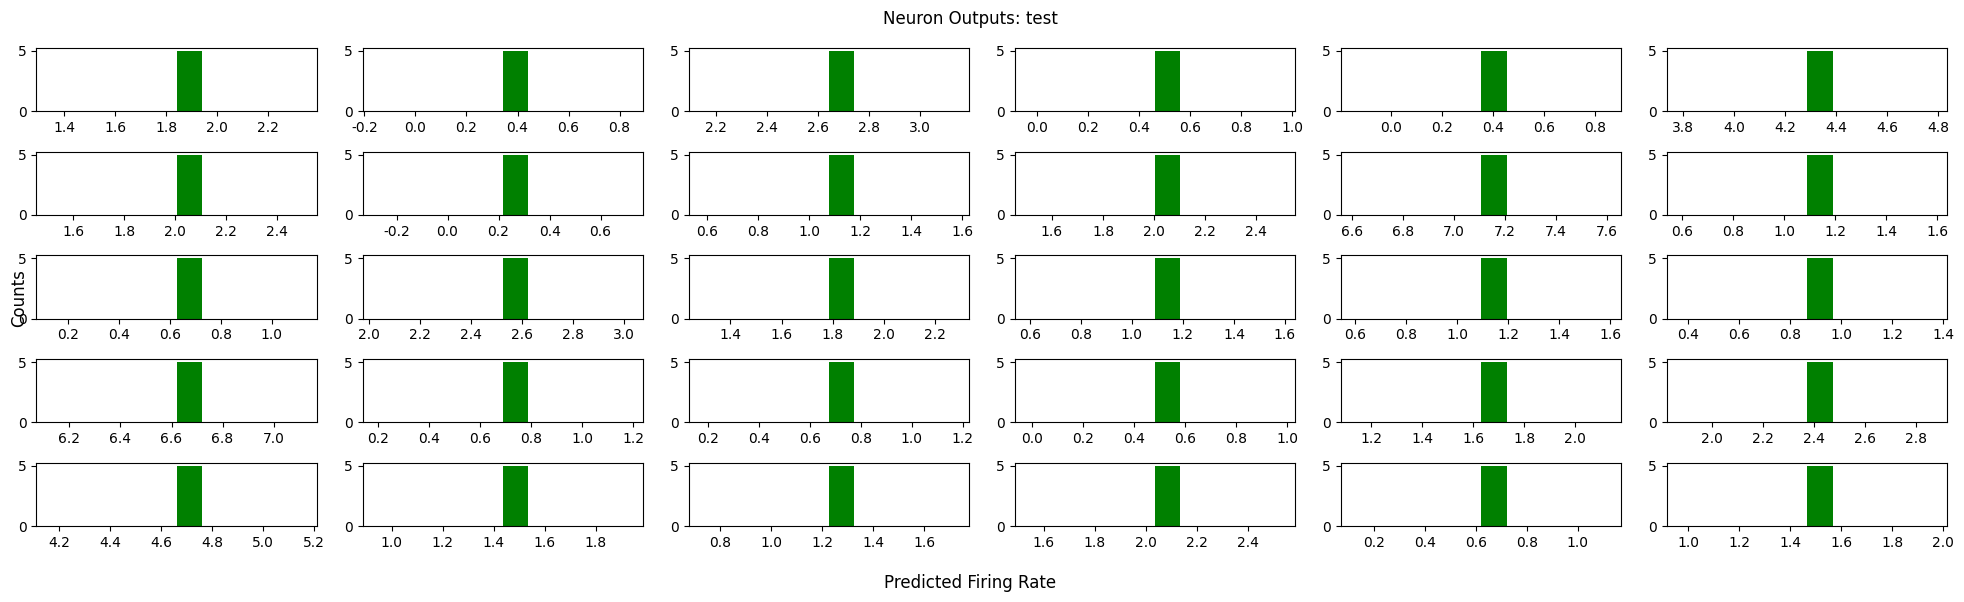

    neuron  p_value
0     1685      1.0
1      368      1.0
2     1571      1.0
3      670      1.0
4     1918      1.0
5     1231      1.0
6     6795      1.0
7     6492      1.0
8     2507      1.0
9     1444      1.0
10    2361      1.0
11    6699      1.0
12    6672      1.0
13    6790      1.0
14    6209      1.0
15    6699      1.0
16    1447      1.0
17    5583      1.0
18    2237      1.0
19    2161      1.0
20    7217      1.0
21    5114      1.0
22    4321      1.0
23    4823      1.0
24    6822      1.0
25    5935      1.0
26     823      1.0
27    6501      1.0
28    6819      1.0
29    5782      1.0


In [22]:
plot_select30_hist(x2, "test", neurons, 'green')